# 12 · Polymer melts and solutions

The flow of a polymer melt is governed by its molecules: their length (molar mass), how strongly they
entangle, and the breadth of the molar-mass distribution. This notebook connects rheological
measurements to molecular parameters - and shows why the industry's favourite single number, the melt
flow index, is not enough.

**What you will learn**
- relate zero-shear viscosity to molar mass (Rouse and entangled regimes)
- estimate the entanglement molar mass from the plateau modulus
- interpret the melt flow index and its limitations

**Before you start:** notebooks 03, 05 and 08  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engrheo import datasets, polymers, models
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Zero-shear viscosity and molar mass
Short chains flow like a Rouse fluid, $\eta_0 \propto M$; above a critical molar mass $M_c$ the chains entangle and
$\eta_0 \propto M^{3.4}$ - a doubling of the molar mass then raises the viscosity about tenfold.

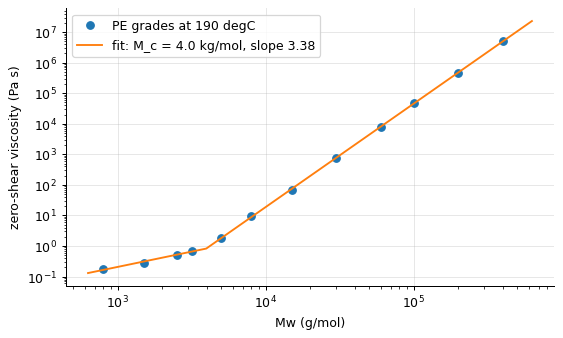

critical molar mass 3.96 kg/mol, exponent above M_c 3.38   (true 4.0 kg/mol, 3.4)
a 20 % higher Mw raises eta0 by a factor 1.85


In [2]:
pe = pd.read_csv(datasets.path("polyethylene_eta0_vs_mw.csv"), comment="#")
M, eta0 = pe.Mw_g_mol.to_numpy(), pe.eta0_Pa_s.to_numpy()

def resid(p):                                        # p = log10 Mc, log10 eta_c, exponent above Mc
    return np.log10(polymers.zero_shear_viscosity(M, 10**p[0], 10**p[1], p[2])) - np.log10(eta0)
fit = optimize.least_squares(resid, [4.0, 0.0, 3.0])
Mc, eta_c, a = 10**fit.x[0], 10**fit.x[1], fit.x[2]
MM = np.logspace(2.8, 5.8, 200)
plt.loglog(M, eta0, "o", label="PE grades at 190 degC")
plt.loglog(MM, polymers.zero_shear_viscosity(MM, Mc, eta_c, a), label=f"fit: M_c = {Mc/1e3:.1f} kg/mol, slope {a:.2f}")
plt.xlabel("Mw (g/mol)"); plt.ylabel("zero-shear viscosity (Pa s)"); plt.legend(); plt.show()
print(f"critical molar mass {Mc/1e3:.2f} kg/mol, exponent above M_c {a:.2f}   (true 4.0 kg/mol, 3.4)")
print(f"a 20 % higher Mw raises eta0 by a factor {1.2**a:.2f}")

The steep power law is why molar mass is controlled so tightly in polymer production: small changes in
chain length make large changes in processability.

## Entanglements from the plateau modulus
The rubbery plateau of a melt's $G'$ (notebook 05) measures the entanglement density: the plateau modulus $G_N^0$
gives the molar mass between entanglements, $M_e = \rho RT/G_N^0$. Estimate $G_N^0$ as $G'$ where $\tan\delta$ is smallest:

In [3]:
melt = pd.read_csv(datasets.path("polystyrene_frequency_sweeps.csv"), comment="#")
m170 = melt[melt.temperature_C == 220]                   # the hottest sweep reaches furthest into the plateau
i = np.argmin(m170.G_loss_Pa / m170.G_storage_Pa)
G_N0 = m170.G_storage_Pa.iloc[i]
print(f"G' at minimum tan(delta): {G_N0:.3g} Pa  ->  M_e = rho R T / G_N0 = {polymers.entanglement_molar_mass(G_N0, 950.0, 493.15):.1f} kg/mol")

G' at minimum tan(delta): 2.2e+05 Pa  ->  M_e = rho R T / G_N0 = 17.7 kg/mol


The minimum of $\tan\delta$ gives only a rough estimate of the plateau - the plateau of this material is not
flat - and the prefactor (1 or 4/5) differs between textbooks, so $M_e$ is uncertain by tens of percent. For
polystyrene the literature value is about 13-18 kg/mol. Note that $M_c$ is typically 2-3 times $M_e$.

## The melt flow index - and its limits
The melt flow index (MFI or MFR) is the mass of polymer extruded through a standard die in 10 minutes
under a standard load. It is a single point on the flow curve, at a low shear rate:

MFI  0.3 g/10 min: wall stress 19.4 kPa, apparent rate    0.75 1/s, apparent viscosity   25866 Pa s
MFI  2.0 g/10 min: wall stress 19.4 kPa, apparent rate    4.99 1/s, apparent viscosity    3880 Pa s
MFI 20.0 g/10 min: wall stress 19.4 kPa, apparent rate   49.90 1/s, apparent viscosity     388 Pa s
narrow distribution: viscosity at 1000 1/s (extrusion)   676.3 Pa s
broad distribution: viscosity at 1000 1/s (extrusion)    95.3 Pa s


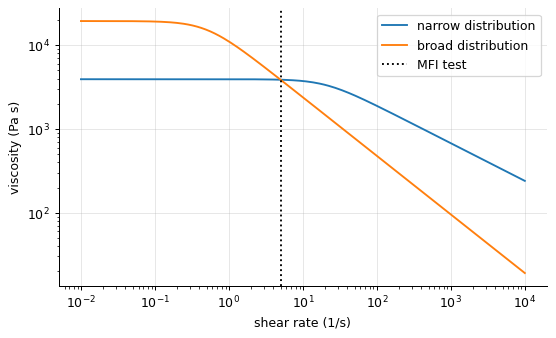

In [4]:
for mfi in (0.3, 2.0, 20.0):
    c = polymers.mfi_conditions(mfi, 2.16, 740.0)       # polyethylene: 190 degC, 2.16 kg, melt density 740 kg/m3
    print(f"MFI {mfi:4.1f} g/10 min: wall stress {c['tau_w']/1e3:.1f} kPa, apparent rate {c['rate_apparent']:7.2f} 1/s, "
          f"apparent viscosity {c['eta_apparent']:7.0f} Pa s")
cond = polymers.mfi_conditions(2.0, 2.16, 740.0)
rr = np.logspace(-2, 4, 200)
eta_target = cond["eta_apparent"]
for name, n_, lam in (("narrow distribution", 0.55, 0.05), ("broad distribution", 0.3, 2.0)):
    # choose eta0 so both grades have the same apparent viscosity at the MFI shear rate
    base = models.viscosity("carreau", cond["rate_apparent"], 1.0, 0.0, lam, n_)
    eta0_ = eta_target / base
    plt.loglog(rr, models.viscosity("carreau", rr, eta0_, 0.0, lam, n_), label=f"{name}")
    print(f"{name}: viscosity at 1000 1/s (extrusion) {models.viscosity('carreau', 1000.0, eta0_, 0.0, lam, n_):7.1f} Pa s")
plt.axvline(cond["rate_apparent"], color="k", ls=":", label="MFI test"); plt.xlabel("shear rate (1/s)"); plt.ylabel("viscosity (Pa s)")
plt.legend(); plt.show()

Two grades with the same MFI can behave very differently in extrusion or injection moulding, where the
shear rates are hundreds of times higher: a broad molar-mass distribution shear-thins more strongly. The MFI
is a useful quality-control number for one grade, but comparing grades needs the flow curve.

## Inside the algorithm: the melt flow index test by hand
The load on the piston produces a pressure $mg/(\pi R_p^2)$; in the die the wall stress is that pressure times
$R/(2L)$, and the apparent rate is $4Q/(\pi R^3)$ with $Q$ = MFI / (density x 600 s):

In [5]:
mfi, load, rho_ = 2.0, 2.16, 740.0
p = load * 9.80665 / (np.pi * (9.55e-3 / 2)**2)
tau_hand = p * (2.095e-3 / 2) / (2 * 8.0e-3)
rate_hand = 4 * (mfi * 1e-3 / rho_ / 600) / (np.pi * (2.095e-3 / 2)**3)
lib = polymers.mfi_conditions(mfi, load, rho_)
print(f"by hand: {tau_hand:.1f} Pa, {rate_hand:.3f} 1/s;  library: {lib['tau_w']:.1f} Pa, {lib['rate_apparent']:.3f} 1/s")

by hand: 19360.3 Pa, 4.990 1/s;  library: 19360.3 Pa, 4.990 1/s


## Exercises
1. Predict the zero-shear viscosity of a 150 kg/mol grade with the fitted relation. How uncertain is the prediction if the exponent is uncertain by +/-0.1?
2. A grade must process at the same viscosity as before, but at a melt temperature 20 K higher (Arrhenius, E_a = 30 kJ/mol for polyethylene). By how much may its molar mass increase?
3. **Implement it yourself:** estimate the exponent above $M_c$ with an ordinary straight-line fit of $\log\eta_0$ against $\log M$ for the grades above 10 kg/mol, and compare with the piecewise fit.